# Tutorial 5 Regularized Linear Models, Cross-validation, Polynomial Regression, Feature Engineering, GAM (STAT3612)

- **Tutor**: Yinong Wang
- **Office**: Rm103, RRS
- **Email**: wangyinong@connect.hku.hk



### Learning Outcomes:

In this tutorial we will learn

1. How to implement regularized linear models with `sklearn`.
2. How to implement cross-validation with `sklearn`.
3. How to implement Polynomial Regression with `numpy`.
4. How to implement Feature Engineering with `sklearn`.
5. How to implement Generalized Additive Models with `pygam`.

## 1. Regularized Linear models (Ridge, Lasso and Elastic Net)
Import necessary packges:

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, lasso_path, Ridge, enet_path, ElasticNetCV

We use the `Iris` dataset for this case study:

In [32]:
# Load the Iris dataset
iris = load_iris()

# Create a pandas DataFrame using the Iris dataset's features
# The columns of the DataFrame are named according to the feature names in the dataset
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add some new features to the DataFrame
# SW2: square of the 'sepal width (cm)' feature
df['SW2'] = df['sepal width (cm)']**2

# PL2: square of the 'petal length (cm)' feature
df['PL2'] = df['petal length (cm)']**2

# PW2: square of the 'petal width (cm)' feature
df['PW2'] = df['petal width (cm)']**2

# Display the first five rows of the DataFrame to inspect the new features
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),SW2,PL2,PW2
0,5.1,3.5,1.4,0.2,12.25,1.96,0.04
1,4.9,3.0,1.4,0.2,9.00,1.96,0.04
2,4.7,3.2,1.3,0.2,10.24,1.69,0.04
3,4.6,3.1,1.5,0.2,9.61,2.25,0.04
4,5.0,3.6,1.4,0.2,12.96,1.96,0.04


In [36]:
# Extract the 'sepal length (cm)' column as the target variable
# Convert it to a NumPy array using .values, which will be used for modeling
target = df['sepal length (cm)'].values

# Extract all columns except the first one ('sepal length (cm)') as features
# The .iloc[:,1:] selects all rows and columns from the second to the last
# Convert these selected columns to a NumPy array using .values
data = df.iloc[:, 1:].values

In [37]:
# Split the dataset into training and testing sets
# The data (features) and target (labels) are split into training and testing subsets
# test_size=0.2 indicates that 20% of the data will be used for testing, and 80% for training
# random_state=42 ensures reproducibility of the results by fixing the random seed
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

# Print the shape of the training feature set
# This shows the number of training samples and features
print(X_train.shape)

# Print the shape of the testing feature set
# This shows the number of testing samples and features
print(X_test.shape)

(120, 6)
(30, 6)


Let's standarlize the dataset:

In [38]:
# Import the StandardScaler from scikit-learn, which is used to standardize features
# Standardization scales the data so that it has a mean of 0 and a standard deviation of 1

from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and then transform it
# Fitting calculates the mean and standard deviation for scaling the training data
# Transforming applies the standardization to the training data
X_train = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
# This ensures the test data is scaled using the same parameters (mean and std) as the training data
X_test = scaler.transform(X_test)

We first fit a linear model:

In [39]:
# Import the LinearRegression model from scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Initialize the linear regression model
reg = LinearRegression()

# Fit the model to the training data
# The model learns the relationship between the features (X_train) and the target (y_train)
reg.fit(X_train, y_train)

# Print the coefficients (weights) of the trained model
# These coefficients represent the influence of each feature on the target variable
print(reg.coef_)

# Use the trained model to make predictions on the test set
# The model predicts the target values (y) based on the test features (X_test)
pred = reg.predict(X_test)

# Calculate and print the Mean Squared Error (MSE) between the predicted values and the actual target values
# MSE measures the average squared difference between the predicted and actual values
# A lower MSE indicates a better fit of the model
print(mean_squared_error(pred, y_test))

[ 0.02995619  0.45482849 -0.01498273  0.23682536  0.67848853 -0.31487613]
0.09141978173596617


### 1.1 Ridge Regression

Ridge regression is a regression model where the loss function is the linear least squares function and regularization is given by the l2-norm. 

Specifically, the objective function is :
$$||y - Xw||^2_2 + \alpha * ||w||^2_2$$

$\alpha$ is the constant that multiplies the L2 term, controlling the regularization strength. $\alpha$ must be a non-negative float i.e. in [0, inf).

The core idea of Ridge regression is to modify the ordinary least squares (OLS) loss function by introducing a penalty term based on the L2-norm (Euclidean norm) of the model's coefficients. This helps shrink the coefficients towards zero, preventing large swings that might otherwise occur due to noisy data or highly correlated features.

In [40]:
n_alphas = 200
alphas = np.linspace(0, 20, n_alphas)

coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, fit_intercept=False)
    ridge.fit(X_train, y_train)
    coefs.append(ridge.coef_)
coefs = np.array(coefs)# Define the number of alpha (regularization strength) values to test
n_alphas = 200

# Generate 200 values of alpha, evenly spaced between 0 and 20
# Alpha controls the regularization strength in Ridge regression
# A higher alpha increases regularization and reduces overfitting, but may underfit the data
alphas = np.linspace(0, 20, n_alphas)

# Initialize an empty list to store the coefficients for each value of alpha
coefs = []

# Loop over each value of alpha
for a in alphas:
    # Initialize the Ridge regression model with the current alpha value
    # Setting fit_intercept=False means the model will not estimate an intercept (bias term)
    ridge = Ridge(alpha=a, fit_intercept=False)
    
    # Fit the Ridge regression model to the training data
    ridge.fit(X_train, y_train)
    
    # Append the model's coefficients (weights) to the coefs list
    # This shows how the coefficients change as alpha changes
    coefs.append(ridge.coef_)

# Convert the list of coefficients to a NumPy array for easier manipulation
coefs = np.array(coefs)

Text(0.5, 1.0, 'L2 Norm')

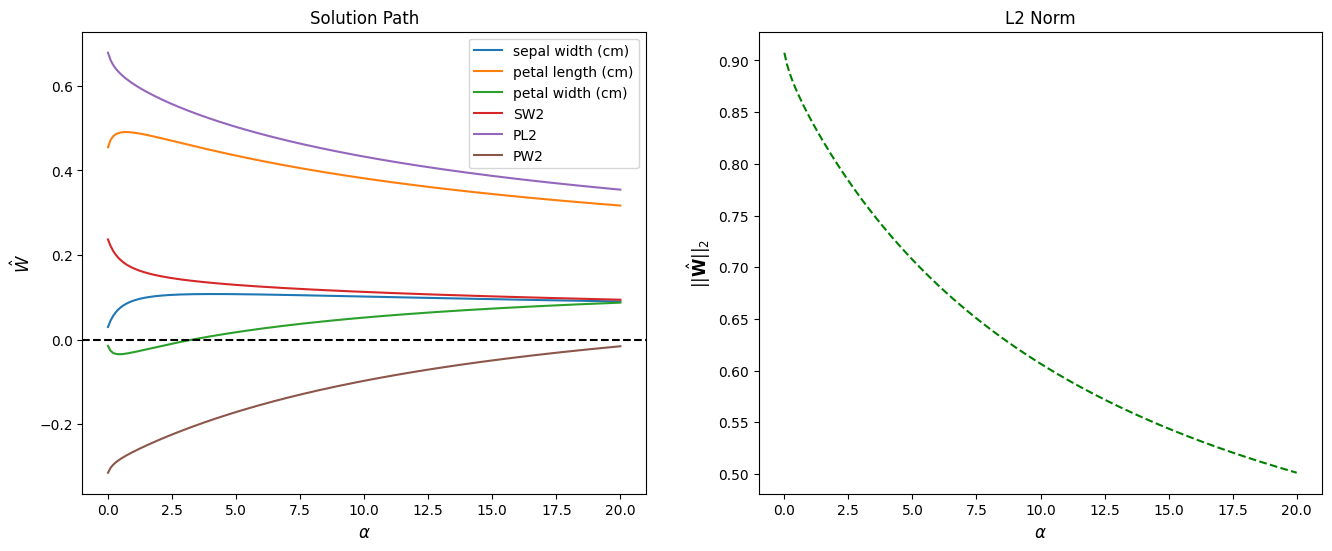

In [42]:
# Create a figure with two subplots (1 row, 2 columns)
# figsize defines the size of the figure, in this case, 16 inches by 6 inches
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Get the feature labels (column names) for the plot, excluding the target variable
labels = df.columns[1:].values

# Loop over each feature in the coefficients matrix
# coefs.shape[1] gives the number of features, and for each feature, we plot its coefficient path
for i in range(coefs.shape[1]):
    # Plot the alpha values on the x-axis and the corresponding coefficients on the y-axis
    # This shows how each feature's coefficient changes as the regularization strength (alpha) changes
    ax1.plot(alphas, coefs[:,i], label=labels[i])

# Add a horizontal line at y=0 for reference, with a dashed black line
ax1.axhline(y=0, xmin=0, xmax=10, color='black', linestyle='--')

# Label the x-axis as alpha (regularization parameter)
ax1.set_xlabel(r'$\alpha$', fontsize=12)

# Label the y-axis as the estimated coefficients (weights)
ax1.set_ylabel(r'$\hat{W}$', fontsize=12)

# Add a title to the first subplot to describe the plot
ax1.set_title('Solution Path', fontsize=12)

# Adjust axis limits to fit the plot tightly
ax1.axis('tight')

# Add a legend to show which line corresponds to which feature
ax1.legend()

# Calculate the L2 norm of the coefficients for each alpha value
# The L2 norm is a measure of the magnitude of the coefficients (the length of the weight vector)
l2norm = np.linalg.norm(coefs, ord=2, axis=1)

# Plot the L2 norm against the alpha values in the second subplot
# This shows how the overall magnitude of the coefficients changes as alpha increases
ax2.plot(alphas, l2norm, '--g')

# Label the x-axis as alpha (regularization parameter)
ax2.set_xlabel(r'$\alpha$', fontsize=12)

# Label the y-axis as the L2 norm of the weight vector
ax2.set_ylabel(r'$||\hat{\mathbf{W}}||_2$', fontsize=12)

# Add a title to the second subplot to describe the plot
ax2.set_title('L2 Norm', fontsize=12)

### 1.2 Lasso Regression

Lasso regression is a linear regression model trained with L1 prior as regularizer.
The optimization objectiev for Lasso is:
$$||y - Xw||^2_2 + \alpha * ||w||_1$$

$\alpha$ is a constant that multiplies the L1 term, controlling regularization strength. alpha must be a non-negative float i.e. in [0, inf).

Unlike Ridge regression, which uses the L2-norm to shrink coefficients, Lasso employs the L1-norm, which has the unique property of driving some coefficients to exactly zero. This makes Lasso especially useful for feature selection in high-dimensional datasets.

In [43]:
n_alphas = 200
alphas = np.logspace(-10, 0, n_alphas)
alphas_lasso, coefs, _ = lasso_path(X_train, y_train, alphas=alphas)
log_alphas_lasso = np.log10(alphas_lasso)

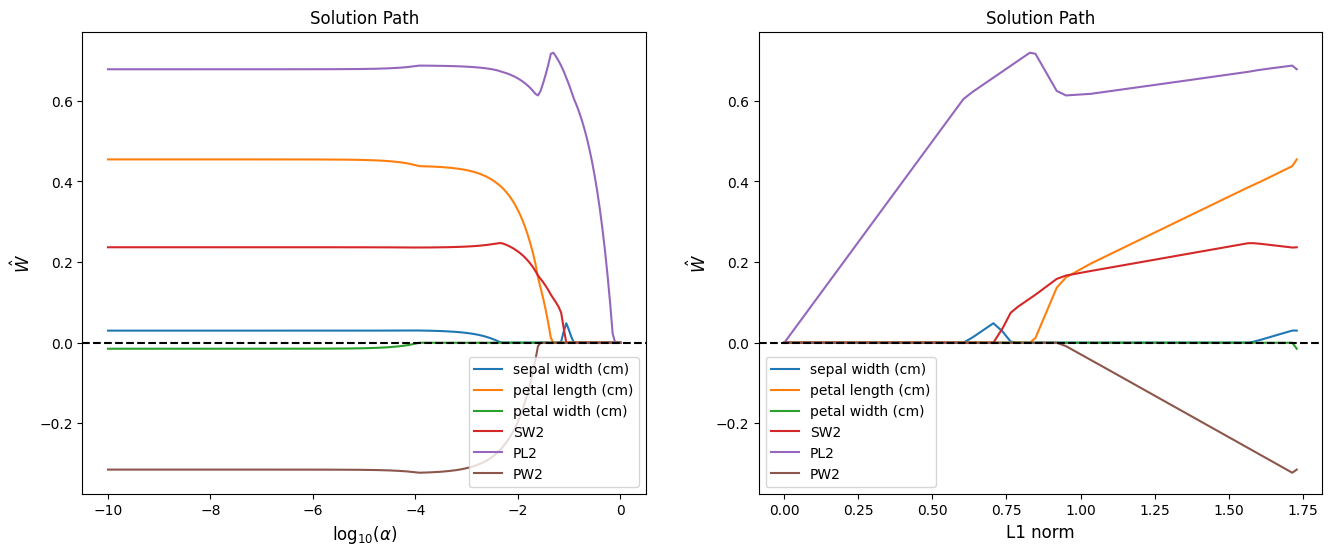

In [44]:
# Create a figure with two subplots (1 row, 2 columns)
# figsize defines the size of the figure, 16 inches by 6 inches
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Plot the solution path for Lasso regression (or similar method) as a function of log(alpha)
# coefs.T represents the transpose of the coefficients matrix, allowing us to iterate over each feature
for i in range(coefs.T.shape[1]):
    # Plot log(alpha) on the x-axis and the corresponding coefficients on the y-axis
    # Each line represents the path of one feature's coefficient as log(alpha) changes
    ax1.plot(log_alphas_lasso, coefs.T[:,i], label=labels[i])

# Add a horizontal line at y=0 for reference, using a dashed black line
ax1.axhline(y=0, xmin=0, xmax=10, color='black', linestyle='--')

# Label the x-axis as log(alpha), the logarithm of the regularization parameter
ax1.set_xlabel(r'$\log_{10}(\alpha)$', fontsize=12)

# Label the y-axis as the estimated coefficients (weights)
ax1.set_ylabel(r'$\hat{W}$', fontsize=12)

# Add a title to the first subplot describing the plot as a solution path
ax1.set_title('Solution Path', fontsize=12)

# Adjust axis limits to fit the plot tightly
ax1.axis('tight')

# Add a legend to show which line corresponds to which feature
ax1.legend()

# Calculate the L1 norm for each alpha value
# The L1 norm is the sum of the absolute values of the coefficients, which encourages sparsity
xx = np.sum(np.abs(coefs.T), axis=1)

# Plot the L1 norm on the x-axis and the corresponding coefficients on the y-axis
# This shows how each feature's coefficient changes as the L1 norm changes
for i in range(coefs.T.shape[1]):
    ax2.plot(xx, coefs.T[:,i], label=labels[i])

# Add a horizontal line at y=0 for reference, using a dashed black line
ax2.axhline(y=0, xmin=0, xmax=1, color='black', linestyle='--')

# Label the x-axis as the L1 norm of the weight vector
ax2.set_xlabel('L1 norm', fontsize=12)

# Label the y-axis as the estimated coefficients (weights)
ax2.set_ylabel(r'$\hat{W}$', fontsize=12)

# Add a title to the second subplot describing the plot as a solution path
ax2.set_title('Solution Path', fontsize=12)

# Adjust axis limits to fit the plot tightly
ax2.axis('tight')

# Add a legend to show which line corresponds to which feature
ax2.legend()

### 1.3 Elastic Net

The elastic net optimization is like this:
$$
|y - Xw||^2_2
+ \alpha * l1\_ratio * ||w||_1
+ 0.5 * \alpha * (1 - l1\_ratio) * ||w||^2_2
$$

The elastic net algorithm uses a weighted combination if L1 and L2 regularization. 
l1\_ratio is a number between 0 and 1 which controls the ratio of L1 and L2 regularization. 
$\alpha$ controls the strength of both L1 and L2 regularization.

In [11]:
n_alphas = 200
l1_ratio = 0.1
alphas = np.logspace(-10, 0, n_alphas)
alphas_enet, coefs, _ = enet_path(X_train, y_train, l1_ratio=l1_ratio, alphas=alphas)
log_alphas_enet = np.log10(alphas_enet)

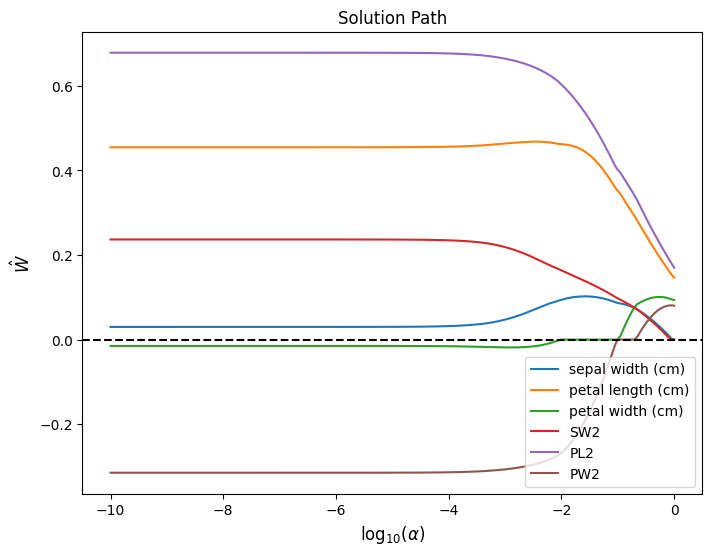

In [12]:
plt.figure(figsize=(8,6))
for i in range(coefs.T.shape[1]):
    plt.plot(log_alphas_enet, coefs.T[:,i],label=labels[i])
plt.axhline(y=0, xmin=0, xmax=10, color='black', linestyle='--')
plt.xlabel(r'$\log_{10}(\alpha)$', fontsize=12)
plt.ylabel(r'$\hat{W}$', fontsize=12)
plt.title('Solution Path', fontsize=12)
plt.axis('tight')
plt.legend()

## 2. Cross validation
Here we try finding the best $\alpha$ by cross validation.

In [46]:
# Here we use all dataset for cross validation

y = df['sepal length (cm)'].values
X = df.iloc[:,1:].values

# center the data before the shrinkage regression
y = y - y.mean()
X = X - X.mean(axis=0)

In [47]:
# Define the number of alpha values to test
n_alphas = 200

# Define the l1_ratio, which controls the balance between Lasso (L1) and Ridge (L2) regularization
# l1_ratio=0.2 means 20% Lasso (L1) and 80% Ridge (L2) regularization
l1_ratio = 0.2

# Generate a logarithmically spaced array of alpha values between 10^-5 and 10^1
# Alpha is the regularization strength in the ElasticNet model
alphas = np.logspace(-5, 1, n_alphas)

# Initialize the ElasticNetCV model with cross-validation
# cv=20 means 20-fold cross-validation to select the best alpha
# l1_ratio controls the mix between Lasso and Ridge penalties
# fit_intercept=False means the model will not estimate an intercept (bias term)
# random_state=42 ensures reproducibility of results by fixing the random seed
model = ElasticNetCV(cv=20, l1_ratio=l1_ratio, alphas=alphas,
                     fit_intercept=False, random_state=42)

# Fit the ElasticNet model to the data
# The model learns the best alpha (regularization strength) and the corresponding coefficients
model.fit(X, y)

# Get the logarithm (base 10) of the alphas used in the model
# This will be used for plotting or analysis purposes
log_alphas = np.log10(model.alphas_)

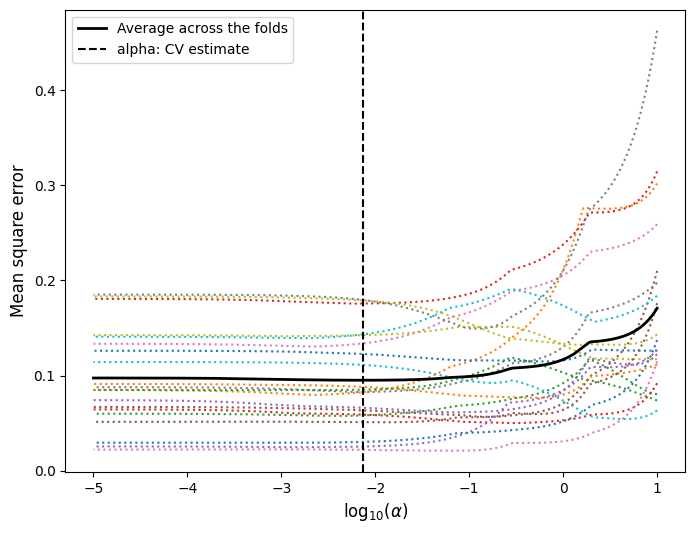

In [49]:
# Create a figure with a size of 8 by 6 inches
plt.figure(figsize=(8, 6))

# Plot the mean squared error (MSE) path for each fold of cross-validation
# model.mse_path_ contains the MSE values for each alpha across the 20 folds
# Each line represents the MSE for a different fold
plt.plot(log_alphas, model.mse_path_, ':')

# Plot the average MSE across all cross-validation folds
# The mean is calculated along the last axis (-1) which represents the folds
# This line shows the general trend of MSE as alpha changes
plt.plot(log_alphas, model.mse_path_.mean(axis=-1), 'k',
         label='Average across the folds', linewidth=2)

# Add a vertical line at the log(alpha) value selected by cross-validation
# model.alpha_ is the alpha value chosen as the best during cross-validation
# This vertical line highlights the optimal alpha
plt.axvline(np.log10(model.alpha_), linestyle='--', color='k',
            label='alpha: CV estimate')

# Label the x-axis as the logarithm of alpha
plt.xlabel(r'$\log_{10}(\alpha)$', fontsize=12)

# Label the y-axis as the mean squared error
plt.ylabel('Mean square error', fontsize=12)

# Adjust the axis limits tightly to fit the plot
plt.axis('tight')

# Add a legend to label the average MSE line and the chosen alpha line
plt.legend()

# Display the plot
plt.show()

## 3. Polynomial Regression

That is, we assume:

$y_i=\beta_0+\beta_1 x_i+\beta_2 x_i^2+\beta_3 x_i^3+\ldots+\beta_d x_i^d+\epsilon_i$

We try to fit $y=sin(x)$ with polynomial regression.

First, let's create some $y=sin(x)$ data points:

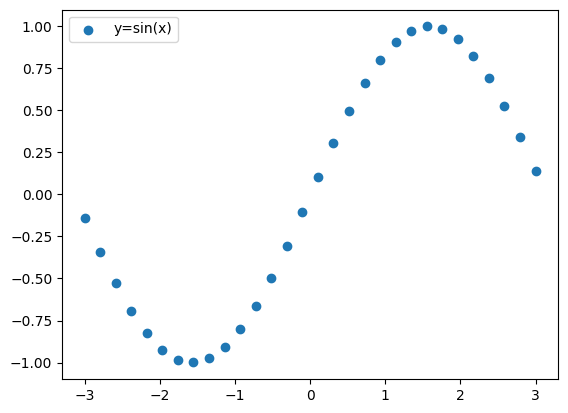

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import math

x = np.linspace(-3, 3, 30)
y = [math.sin(i) for i in x]

plt.scatter(x, y, label='y=sin(x)')
plt.legend()
plt.show()

`numpy.polyfit`:

- Fit a polynomial $p(x) = p_0 * x^{deg} + p_1 * x^{deg-1} + ... + p_{deg}$ of degree $deg$ to points (x, y). 

- Returns a vector of coefficients $p$ that minimises the squared error in the order $deg, deg-1, …$ 

Let's see how it works with degree = 1:

In [17]:
degree = 1
fit_res = np.polyfit(x, y, degree)
fit_res

array([ 3.15982472e-01, -3.04047097e-17])

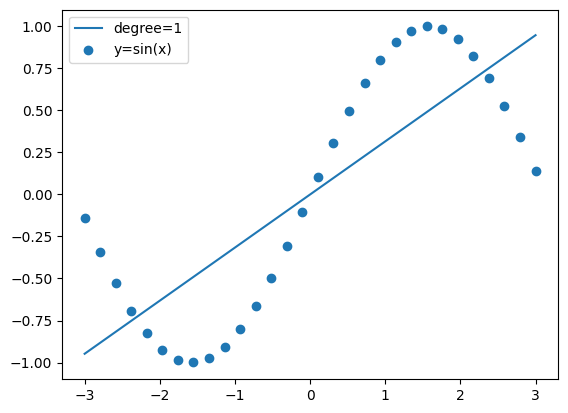

In [18]:
polyd1 = np.poly1d(fit_res)
plt.scatter(x, y, label='y=sin(x)')
plt.plot(x, polyd1(x), label='degree=1')
plt.legend()
plt.show()

Now let's increase the degree:

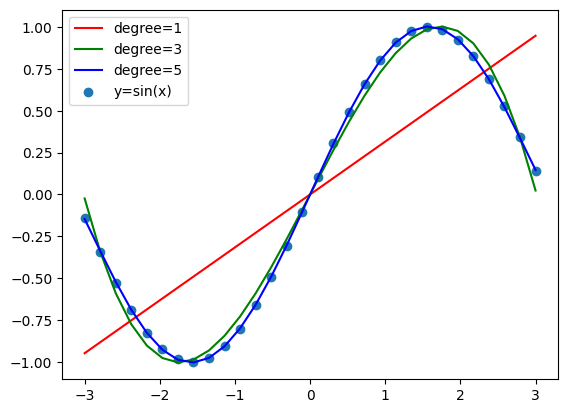

In [19]:
polyd3 = np.poly1d(np.polyfit(x, y, 3)) 
polyd5 = np.poly1d(np.polyfit(x, y, 5)) 
plt.scatter(x, y, label='y=sin(x)')
plt.plot(x, polyd1(x), color='r', label='degree=1')
plt.plot(x, polyd3(x), color='g', label='degree=3')
plt.plot(x, polyd5(x), color='b', label='degree=5')
plt.legend()
plt.show()

Let's see how the function generalize to $y=sin(x)$:

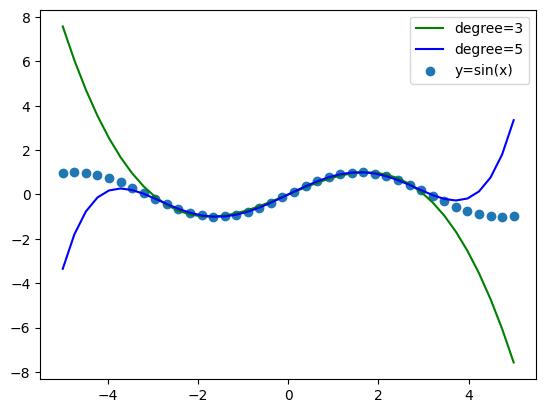

In [20]:
xx = np.linspace(-5, 5, 40)
plt.scatter(xx, [math.sin(i) for i in xx], label='y=sin(x)')
plt.plot(xx, polyd3(xx), color='g', label='degree=3')
plt.plot(xx, polyd5(xx), color='b', label='degree=5')
plt.legend()
plt.show()

## 4. Feature Engineering

`sklearn.preprocessing.StandardScaler`:

Standardize features by removing the mean and scaling to unit variance.

$z = (x - u) / s$

where $u$ is the mean, and $s$ is the standard deviation

In [21]:
from sklearn import preprocessing

X_train = np.array([[ 1., -1.,  2.],
                    [ 2.,  0.,  0.],
                    [ 0.,  1., -1.]])
scaler = preprocessing.StandardScaler().fit(X_train)

In [22]:
print(scaler.mean_)
print(scaler.scale_)

[1.         0.         0.33333333]
[0.81649658 0.81649658 1.24721913]


In [23]:
X_scaled = scaler.transform(X_train)
X_scaled

array([[ 0.        , -1.22474487,  1.33630621],
       [ 1.22474487,  0.        , -0.26726124],
       [-1.22474487,  1.22474487, -1.06904497]])

In [24]:
print(X_scaled.mean(axis=0))
print(X_scaled.std(axis=0))

[0. 0. 0.]
[1. 1. 1.]


`sklearn.preprocessing.MinMaxScaler`:

Transform features by scaling each feature to a given range:

- X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

- X_scaled = X_std * (max - min) + min

where min, max = feature_range.

In [25]:
X_train = np.array([[ 1., -1.,  2.],
                    [ 2.,  0.,  0.],
                    [ 0.,  1., -1.]])

min_max_scaler = preprocessing.MinMaxScaler()
X_train_minmax = min_max_scaler.fit_transform(X_train)
X_train_minmax

array([[0.5       , 0.        , 1.        ],
       [1.        , 0.5       , 0.33333333],
       [0.        , 1.        , 0.        ]])

In [26]:
X_test = np.array([[-3., -1.,  4.]])
X_test_minmax = min_max_scaler.transform(X_test)
X_test_minmax

array([[-1.5       ,  0.        ,  1.66666667]])

In [27]:
print(min_max_scaler.scale_)
print(min_max_scaler.min_)

[0.5        0.5        0.33333333]
[0.         0.5        0.33333333]


## 5. Generalized Additive Models

$$y \sim \text { ExponentialFamily }(\mu \mid X)$$

where

$$g(\mu \mid X)=\beta_0+f_1\left(X_1\right)+f_2\left(X_2, X 3\right)+\ldots+f_M\left(X_N\right)$$

So we can see that a GAM has 3 components:

- distribution from the exponential family
- link function $g(⋅)$
- functional form with an additive structure $\beta_0+f_1\left(X_1\right)+f_2\left(X_2, X 3\right)+\ldots+f_M\left(X_N\right)$


we will use [pyGAM](https://pygam.readthedocs.io/en/latest/) to implement a GAM example.


In [50]:
# !pip install pygam

Use `chicago` dataset in `pygam`:
- X contains `'time', 'tmpd', 'pm10median', 'o3median'`, with no NaNs
- y contains `'death'`, the deaths per day, with no NaNs

In [29]:
from pygam.datasets import chicago
X, y = chicago(return_X_y=True)

In `pygam` we can define our GAM by:

`distribution`:
- `normal`
- `binomial`
- `poisson`
- `gamma`
- `inv_gauss`

`link function`:
- `identity`
- `logit`
- `inverse`
- `log`
- `inverse-squared`

`functional Form`:
- `l()` linear terms: for terms like $X_i$
- `s()` spline terms
- `f()` factor terms
- `te()` tensor products(interactions)
- `intercept`

More detials can be find in [here](https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html).

In [30]:
from pygam import PoissonGAM, s, te

gam = PoissonGAM(s(0, n_splines=200) + te(3, 1) + s(2)).fit(X, y)

To understand the relationship between some feature and the response variable in our fitted GAM, we can plot some 3D surface.

Here, we foucus on `te(3, 1)`, see how `y` change with these two features:

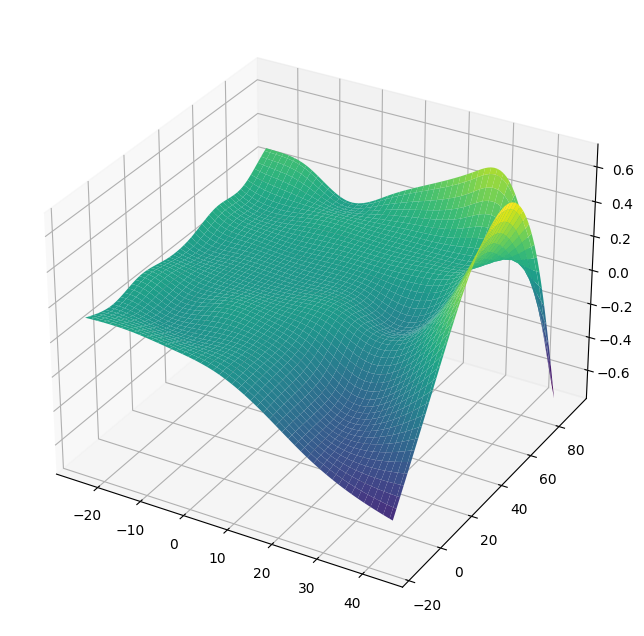

In [31]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

plt.ion()
plt.rcParams['figure.figsize'] = (12, 8)
# generate a grid for te(3, 1) term
XX = gam.generate_X_grid(term=1, meshgrid=True)
# calculate y on the grid with other features fixed
Z = gam.partial_dependence(term=1, X=XX, meshgrid=True)
# plot the 3-D surface
ax = plt.axes(projection='3d')
ax.plot_surface(XX[0], XX[1], Z, cmap='viridis')